# Violencia en Tech — Notebook 03: Limpieza y Preprocesamiento

**Proyecto:** Sistema de Análisis de Violencia Simbólica contra Mujeres en Tecnología  
**Autora:** Maricarmen Camacho Pérez — UAEH, Ciencias Computacionales  
**Input:** `data/processed/reddit_data_analizado.csv`  
**Output:** `data/processed/reddit_data_limpio.csv`  

---
**Pipeline:** 01_Extraccion → 02_EDA → **03_Limpieza** → 04_Reglas → 05_BERT → 06_Temporal → Final

---

### ¿Qué hace este notebook?
1. Carga el dataset del Notebook 02 (con columnas de tiempo y longitud)
2. Aplica un pipeline de limpieza de texto en 7 pasos (URLs, menciones, etc.)
3. Aplica 4 filtros de calidad (borrados, cortos, no inglés, NSFW)
4. Guarda el corpus limpio para el clasificador de reglas (Notebook 04)

### ¿Por qué NO se eliminan stopwords ni se aplica lematización?
Purnomo et al. (2025) probaron 16 combinaciones de preprocesamiento con BERT  
y encontraron que para textos cortos, lo mejor es no quitar nada porque  
cada palabra aporta información al contexto que BERT necesita.

---
## 1. Librerías

In [9]:
# ══════════════════════════════════════════════════════════
# IMPORTACIÓN DE LIBRERÍAS
# ══════════════════════════════════════════════════════════

import pandas as pd          # Manipulación de datos en tablas (DataFrames)
import numpy as np           # Operaciones numéricas
import re                    # Expresiones regulares para buscar y reemplazar patrones en texto
from datetime import datetime # Manejo de fechas
import matplotlib.pyplot as plt  # Crear gráficas
import os                    # Manejar rutas de archivos y carpetas
import warnings              # Controlar mensajes de advertencia

warnings.filterwarnings("ignore")  # Ocultar warnings

# Paleta de colores del proyecto
PALETTE = {
    "primario":   "#2C5F8A",  # Azul oscuro
    "secundario": "#E84E4F",  # Rojo
    "acento":     "#F5A623",  # Naranja
    "neutral":    "#4CAF50",  # Verde
}

# Crear carpeta de imágenes si no existe
os.makedirs("../images/exploratorio", exist_ok=True)

print(f"Preprocesamiento iniciado: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Preprocesamiento iniciado: 2026-03-18 19:30


---
## 2. Cargar datos

Se carga el dataset generado por el Notebook 02, que ya tiene  
las columnas de tiempo (año, mes, año_mes) y longitud (num_palabras).

In [10]:
# ══════════════════════════════════════════════════════════
# CARGAR EL DATASET DEL NOTEBOOK 02
# ══════════════════════════════════════════════════════════

# Leer el CSV generado por el Notebook 02
df = pd.read_csv("../data/processed/reddit_data_analizado.csv")

# Convertir la columna de fecha de string a datetime
df["fecha"] = pd.to_datetime(df["fecha"], utc=True)

# Guardar el total original para calcular la tasa de retención al final
# Así no necesitamos volver a leer el CSV (más rápido y más limpio)
TOTAL_ORIGINAL = len(df)

print(f"Registros antes de limpieza: {TOTAL_ORIGINAL:,}")
print(f"Columnas: {df.columns.tolist()}")

Registros antes de limpieza: 201,182
Columnas: ['id', 'tipo', 'subreddit', 'titulo', 'texto', 'texto_completo', 'autor', 'fecha', 'año', 'mes', 'año_mes', 'upvotes', 'num_comentarios', 'url', 'keyword', 'trimestre', 'num_palabras', 'num_caracteres']


---
## 3. Funciones de limpieza de texto

Se definen dos funciones:
- `limpiar_texto()`: aplica 7 pasos de limpieza al texto crudo
- `calcular_idioma_probable()`: detecta si el texto está en inglés  
  usando una heurística basada en stopwords

In [11]:
def limpiar_texto(texto):
    """
    Aplica un pipeline de 7 pasos de limpieza al texto crudo de Reddit.
    
    ¿Por qué este orden?
    El orden importa. Por ejemplo, primero quitamos URLs y después
    caracteres especiales. Si lo hiciéramos al revés, las URLs se
    romperían en pedazos y quedarían fragmentos difíciles de limpiar.
    
    ¿Por qué NO se quitan stopwords?
    Porque BERT necesita el contexto completo del texto para entenderlo.
    Purnomo et al. (2025) demostraron que quitar stopwords empeora
    el rendimiento de BERT en textos cortos.
    
    Parámetros:
        texto: string con el texto crudo de Reddit
    Retorna:
        string con el texto limpio
    """
    # Si el texto es nulo (NaN), devolver string vacío
    if pd.isna(texto):
        return ""

    # PASO 1: Convertir todo a minúsculas
    # ¿Por qué? Porque "Women" y "women" deben tratarse igual.
    # Además, bert-base-uncased espera texto en minúsculas.
    texto = str(texto).lower()

    # PASO 2: Eliminar URLs (enlaces web)
    # Patrón: cualquier cosa que empiece con http o www seguido de caracteres sin espacio
    # Ejemplo: "mira esto http://example.com" → "mira esto "
    texto = re.sub(r"http\S+|www\.\S+", "", texto)

    # PASO 3: Eliminar menciones de usuario (@usuario)
    # Patrón: @ seguido de caracteres alfanuméricos
    # Ejemplo: "@johndoe dijo que" → " dijo que"
    texto = re.sub(r"@\w+", "", texto)

    # PASO 4: Eliminar referencias a subreddits (r/nombre)
    # Patrón: r/ seguido de caracteres alfanuméricos
    # Ejemplo: "lo vi en r/WomenInTech" → "lo vi en "
    texto = re.sub(r"r/\w+", "", texto)

    # PASO 5: Normalizar saltos de línea y tabulaciones
    # Los reemplazamos por un espacio simple
    # Ejemplo: "línea 1\nlínea 2" → "línea 1 línea 2"
    texto = re.sub(r"\n|\r|\t", " ", texto)

    # PASO 6: Eliminar caracteres especiales que no aportan significado
    # Se CONSERVAN: letras, números, espacios, apóstrofos, puntuación básica
    # Se ELIMINAN: emojis, caracteres Unicode raros, markdown de Reddit
    # ¿Por qué conservar puntuación? Porque ayuda a BERT a entender la estructura
    texto = re.sub(r"[^\w\s'.,!?;:()\-]", " ", texto)

    # PASO 7: Normalizar espacios múltiples a uno solo
    # Los pasos anteriores pueden dejar espacios dobles o triples
    # Ejemplo: "hola   mundo" → "hola mundo"
    # .strip() quita espacios al inicio y final del texto
    texto = re.sub(r"\s+", " ", texto).strip()

    return texto


def calcular_idioma_probable(texto):
    """
    Detecta si un texto está probablemente en inglés usando una heurística
    basada en la presencia de palabras funcionales comunes (stopwords).
    
    VERSIÓN MEJORADA: lista de stopwords ampliada de 20 a 40 palabras
    y umbral reducido a 1 para no eliminar textos cortos en inglés.
    
    Parámetros:
        texto (str): texto ya limpio
    Retorna:
        str: "en" si es inglés, "otro" si no, "desconocido" si es muy corto
    """
    # Textos vacíos o de 1-2 palabras no se pueden clasificar
    if not texto or len(texto.split()) < 3:
        return "desconocido"

    # 40 palabras funcionales muy comunes en inglés (ampliada)
    # Se agregaron: you, they, this, but, not, do, have, can, etc.
    # que son muy frecuentes en textos cortos de Reddit
    stopwords_en = {
        "the", "and", "is", "in", "it", "to", "of", "a", "that", "was",
        "for", "on", "are", "as", "with", "his", "her", "i", "my", "we",
        "you", "your", "they", "this", "but", "not", "have", "do", "can",
        "would", "been", "from", "or", "an", "will", "about", "just",
        "if", "so", "what",
    }

    # Convertir texto a conjunto de palabras únicas
    palabras = set(texto.lower().split())
    coincidencias = len(palabras & stopwords_en)  # Intersección

    # Umbral reducido a 1 (antes era 2)
    # Con la lista ampliada, 1 coincidencia es suficiente
    # para confirmar que el texto es inglés
    return "en" if coincidencias >= 1 else "otro"


print("Funciones de limpieza definidas.")

Funciones de limpieza definidas.


---
## 4. Aplicar limpieza al corpus

Se aplica la función `limpiar_texto()` a cada registro del dataset.  
Esto puede tardar 1-2 minutos dependiendo del tamaño del corpus.

In [12]:
# ══════════════════════════════════════════════════════════
# APLICAR LIMPIEZA DE TEXTO
# ══════════════════════════════════════════════════════════

print("Aplicando limpieza de texto...")

# Asegurar que la columna texto_completo no tiene valores nulos
# fillna("") reemplaza NaN por string vacío
# .astype(str) convierte todo a string por si hay valores numéricos
df["texto_completo"] = df["texto_completo"].fillna("").astype(str)

# Aplicar la función de limpieza a cada texto
# .apply() ejecuta la función fila por fila — puede tardar 1-2 minutos
df["texto_limpio"] = df["texto_completo"].apply(limpiar_texto)

# Calcular métricas de longitud del texto ya limpio
# Estas métricas se usan para los filtros de calidad y para las gráficas
df["num_palabras_limpio"]   = df["texto_limpio"].apply(lambda x: len(x.split()))  # Contar palabras
df["num_caracteres_limpio"] = df["texto_limpio"].apply(len)  # Contar caracteres

# Detectar idioma con la heurística de stopwords
# Esto se usa en el Filtro 3 para eliminar textos que no están en inglés
df["idioma"] = df["texto_limpio"].apply(calcular_idioma_probable)

print(f"Limpieza completada.")
print(f"\nDistribución de idioma detectado:")
# Mostrar cuántos textos hay en cada idioma
for idioma, count in df["idioma"].value_counts().items():
    print(f"  {idioma:12s} : {count:>7,} ({count/len(df)*100:.1f}%)")

Aplicando limpieza de texto...
Limpieza completada.

Distribución de idioma detectado:
  en           : 187,077 (93.0%)
  desconocido  :  11,830 (5.9%)
  otro         :   2,275 (1.1%)


---
## 5. Filtros de calidad

Se aplican 4 filtros para eliminar registros que no serían útiles  
para el clasificador:

1. **Textos borrados:** Reddit marca como `[deleted]` o `[removed]`
2. **Textos muy cortos:** Menos de 5 palabras no tienen contexto suficiente
3. **No inglés:** El modelo BERT está entrenado en inglés
4. **NSFW:** Contenido para adultos que podría sesgar el análisis

In [13]:
# ══════════════════════════════════════════════════════════
# FILTROS DE CALIDAD
# Cada filtro elimina registros que no aportan al análisis
# Se aplican en orden y se reporta cuántos registros elimina cada uno
# ══════════════════════════════════════════════════════════

print("Filtros de calidad:")
print(f"  Registros iniciales: {len(df):,}")

# ── FILTRO 1: Textos eliminados por el usuario o moderadores ──
# Reddit reemplaza el contenido con "[deleted]" cuando el usuario borra su post
# y con "[removed]" cuando un moderador lo elimina
# Estos textos no tienen contenido útil
mask_borrados = df["texto_limpio"].isin(["[deleted]", "[removed]", "deleted", "removed", ""])
n_borrados = mask_borrados.sum()  # Contar cuántos cumplen la condición
df = df[~mask_borrados].copy()    # ~ invierte la máscara: quedarse con los que NO son borrados
print(f"  Filtro 1 — Borrados por usuario/mod : {n_borrados:,}")

# ── FILTRO 2: Textos demasiado cortos ────────────────────
# Textos de menos de 5 palabras no tienen suficiente contexto
# para que el clasificador de reglas o BERT trabajen correctamente
# Ejemplo: "lol", "thanks!", "this" → no aportan información
MINIMO_PALABRAS = 5
mask_cortos = df["num_palabras_limpio"] < MINIMO_PALABRAS  # Textos con menos de 5 palabras
n_cortos = mask_cortos.sum()
df = df[~mask_cortos].copy()  # Quedarse solo con los que tienen 5+ palabras
print(f"  Filtro 2 — Menos de {MINIMO_PALABRAS} palabras      : {n_cortos:,}")

# ── FILTRO 3: Solo textos en inglés ──────────────────────
# El modelo BERT que usaremos (bert-base-uncased) está entrenado en inglés
# Textos en español, portugués, etc. darían resultados incorrectos
mask_no_en = df["idioma"] != "en"  # Todos los que NO son inglés
n_no_en = mask_no_en.sum()
df = df[~mask_no_en].copy()  # Quedarse solo con inglés
print(f"  Filtro 3 — No inglés                : {n_no_en:,}")

# ── Verificar qué eliminó el filtro de idioma ────────────
# Veamos 10 ejemplos aleatorios de textos clasificados como "no inglés"
# para confirmar que la heurística está funcionando bien

# Necesitamos correr esto ANTES de aplicar el filtro (o guardar los eliminados)
# Aquí mostramos del DataFrame original antes de filtrar
df_no_en = pd.read_csv("../data/processed/reddit_data_analizado.csv")
df_no_en["texto_completo"] = df_no_en["texto_completo"].fillna("").astype(str)
df_no_en["texto_limpio"] = df_no_en["texto_completo"].apply(limpiar_texto)
df_no_en["idioma"] = df_no_en["texto_limpio"].apply(calcular_idioma_probable)

# Mostrar 10 ejemplos de textos marcados como "otro"
print("Ejemplos de textos eliminados por el filtro de idioma:")
print("=" * 60)
for _, row in df_no_en[df_no_en["idioma"] == "otro"].sample(10, random_state=42).iterrows():
    print(f"\n[{row['subreddit']}] {row['texto_limpio'][:150]}...")


# ── FILTRO 4: Contenido NSFW ─────────────────────────────
# Posts marcados como NSFW (Not Safe For Work / contenido adulto)
# podrían sesgar el análisis hacia contenido sexual en vez de violencia simbólica
# Solo se aplica si la columna existe (algunos datasets no la tienen)
if "es_nsfw" in df.columns:
    mask_nsfw = df["es_nsfw"] == True  # Posts marcados como NSFW
    n_nsfw = mask_nsfw.sum()
    df = df[~mask_nsfw].copy()  # Quedarse con los que NO son NSFW
    print(f"  Filtro 4 — NSFW                     : {n_nsfw:,}")

# ── Resumen ──────────────────────────────────────────────
# Calcular tasa de retención usando TOTAL_ORIGINAL (guardado al inicio)
# No volvemos a leer el CSV porque es lento e innecesario
tasa_retencion = len(df) / TOTAL_ORIGINAL * 100
print(f"\n  Registros finales : {len(df):,}")
print(f"  Tasa de retención : {tasa_retencion:.1f}%")

Filtros de calidad:
  Registros iniciales: 201,182
  Filtro 1 — Borrados por usuario/mod : 8,825
  Filtro 2 — Menos de 5 palabras      : 6,902
  Filtro 3 — No inglés                : 883
Ejemplos de textos eliminados por el filtro de idioma:

[antiwork] typical corporate scum...

[webdev] check out sometime...

[experienceddevs] true. they're still there (doing nothing) though....

[LadiesofScience] check out genius lab gear s marie lab coat...

[cscareerquestions] who ever negotiates better....

[webdev] ideas aren't worth anything...

[cscareerquestions] great answer, thank you!...

[TwoXChromosomes] great idea, thank you!...

[girlsgonewired] signed up !...

[webdev] let's centralise all dev tools!...

  Registros finales : 184,572
  Tasa de retención : 91.7%


---
## 6. Comparar antes y después de la limpieza

Gráfica que muestra cómo cambió la distribución de longitud  
de los textos después de aplicar los filtros de calidad.

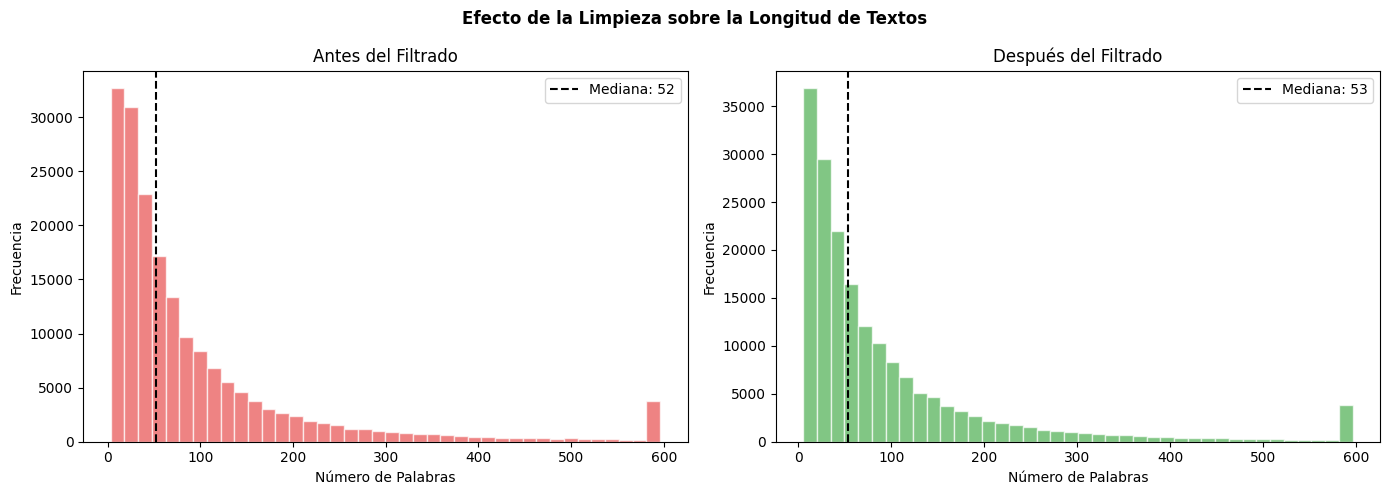

Figura guardada: ../images/exploratorio/03_limpieza_comparativa.png


In [14]:
# ══════════════════════════════════════════════════════════
# COMPARACIÓN ANTES VS DESPUÉS DE LA LIMPIEZA
# Dos histogramas lado a lado mostrando la distribución de longitud
# ══════════════════════════════════════════════════════════

# Crear figura con 2 gráficas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Efecto de la Limpieza sobre la Longitud de Textos", fontweight="bold")

# Determinar qué columna usar para "antes"
# Si existe num_palabras (del notebook 02), usarla; si no, usar num_palabras_limpio
col_antes = "num_palabras" if "num_palabras" in df.columns else "num_palabras_limpio"

# Calcular límite para el eje X usando percentil 98
# Esto recorta los textos extremadamente largos que aplastarían el histograma
limite = df["num_palabras_limpio"].quantile(0.98)

# ── Panel izquierdo: ANTES del filtrado ──────────────────
ax = axes[0]
ax.hist(df[col_antes].clip(upper=limite),  # .clip recorta valores por encima del límite
        bins=40,                            # 40 barras en el histograma
        color=PALETTE["secundario"],         # Rojo
        alpha=0.7,                          # Semitransparente
        edgecolor="white")                   # Bordes blancos
ax.set_title("Antes del Filtrado")
ax.set_xlabel("Número de Palabras")
ax.set_ylabel("Frecuencia")
# Línea vertical en la mediana
ax.axvline(df[col_antes].median(), color="black", linestyle="--",
           label=f"Mediana: {df[col_antes].median():.0f}")
ax.legend()

# ── Panel derecho: DESPUÉS del filtrado ──────────────────
ax = axes[1]
ax.hist(df["num_palabras_limpio"].clip(upper=limite),
        bins=40,
        color=PALETTE["neutral"],  # Verde
        alpha=0.7,
        edgecolor="white")
ax.set_title("Después del Filtrado")
ax.set_xlabel("Número de Palabras")
ax.set_ylabel("Frecuencia")
ax.axvline(df["num_palabras_limpio"].median(), color="black", linestyle="--",
           label=f"Mediana: {df['num_palabras_limpio'].median():.0f}")
ax.legend()

# Guardar la figura
plt.tight_layout()
ruta_fig = "../images/exploratorio/03_limpieza_comparativa.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {ruta_fig}")

---
## 7. Guardar dataset limpio

Se seleccionan solo las columnas necesarias para los siguientes notebooks  
y se renombra `texto_limpio` → `texto` para mayor claridad.

In [15]:
# ══════════════════════════════════════════════════════════
# GUARDAR EL DATASET LIMPIO
# Solo guardamos las columnas que necesitan los siguientes notebooks
# para reducir el tamaño del archivo y evitar confusión
# ══════════════════════════════════════════════════════════

# Columnas que necesitan los notebooks 04 en adelante
columnas_finales = [
    "id",                # Identificador único del texto en Reddit
    "tipo",              # "post" o "comment"
    "subreddit",         # Nombre de la comunidad
    "texto_limpio",      # Texto procesado (lo usará el clasificador)
    "texto_completo",    # Texto original (para validación manual)
    "fecha",             # Fecha de publicación
    "año",               # Año extraído
    "mes",               # Mes extraído
    "año_mes",           # Formato "2024-03" para timeline
    "upvotes",           # Puntuación del texto
    "num_palabras_limpio",# Longitud en palabras del texto limpio
    "keyword",           # Palabra clave que encontró este texto
]

# Solo incluir columnas que realmente existen en el DataFrame
# (por si alguna no se creó en algún paso)
columnas_finales = [c for c in columnas_finales if c in df.columns]

# Crear copia con solo esas columnas
df_limpio = df[columnas_finales].copy()

# Renombrar texto_limpio → texto para mayor claridad
# A partir de aquí, todos los notebooks usan la columna "texto"
df_limpio = df_limpio.rename(columns={"texto_limpio": "texto"})

# Guardar en data/processed/
ruta_salida = "../data/processed/reddit_data_limpio.csv"
df_limpio.to_csv(ruta_salida, index=False, encoding="utf-8")

# ── Resumen final ────────────────────────────────────────
print("=" * 55)
print("RESUMEN — NOTEBOOK 03: LIMPIEZA")
print("=" * 55)
print(f"  Registros originales : {TOTAL_ORIGINAL:,}")
print(f"  Registros finales    : {len(df_limpio):,}")
print(f"  Eliminados           : {TOTAL_ORIGINAL - len(df_limpio):,}")
print(f"  Tasa de retención    : {len(df_limpio)/TOTAL_ORIGINAL*100:.1f}%")
print(f"  Mediana de palabras  : {df_limpio['num_palabras_limpio'].median():.0f}")
print(f"  Columnas             : {df_limpio.columns.tolist()}")
print(f"  Dataset guardado     : {ruta_salida}")
print("=" * 55)
print("\n→ Siguiente paso: notebooks/04_Clasificacion_Reglas.ipynb")

RESUMEN — NOTEBOOK 03: LIMPIEZA
  Registros originales : 201,182
  Registros finales    : 184,572
  Eliminados           : 16,610
  Tasa de retención    : 91.7%
  Mediana de palabras  : 53
  Columnas             : ['id', 'tipo', 'subreddit', 'texto', 'texto_completo', 'fecha', 'año', 'mes', 'año_mes', 'upvotes', 'num_palabras_limpio', 'keyword']
  Dataset guardado     : ../data/processed/reddit_data_limpio.csv

→ Siguiente paso: notebooks/04_Clasificacion_Reglas.ipynb
